In [ ]:
!pip install -q transformers datasets peft accelerate bitsandbytes scikit-learn
!pip install -U fsspec==2025.3.2

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import json
import shutil
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, default_data_collator
from peft import LoraConfig, get_peft_model

In [14]:
os.environ["WANDB_DISABLED"] = "true"
# Load the uploaded CSV file
csv_path = "./mushrooms.csv"
df = pd.read_csv(csv_path)
# Use full dataset
df["class_label"] = df["class"].map({"e": "edible", "p": "poisonous"})

# Generate natural language description
def generate_descriptions(row):
    features = [f"{col.replace('-', ' ')}: {row[col]}" for col in df.columns if col not in ["class", "class_label"]]
    return ', '.join(features)

df["description"] = df.apply(generate_descriptions, axis=1)

# Generate prompt styles
def make_prompt(style, description):
    if style == "short":
        return description
    elif style == "verbose":
        return f"This mushroom has the following properties: {description}. Can you tell if it is edible or poisonous?"
    elif style == "cot":
        return f"Let's think step by step. The mushroom has {description}. Based on these, classify it:"
    else:
        return description

# Generate full jsonl content
def generate_jsonl(style, split="train"):
    data = []
    for _, row in df.iterrows():
        prompt = {
            "instruction": {
                "short": "Classify the mushroom as edible or poisonous.",
                "verbose": "Determine the edibility of the mushroom.",
                "cot": "Think through the features and decide: edible or poisonous?"
            }[style],
            "input": make_prompt(style, row["description"]),
            "output": row["class_label"]
        }
        data.append(prompt)

    # Train/test split
    train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
    return train_data if split == "train" else test_data

# Save all styles to JSONL
for style in ["short", "verbose", "cot"]:
    with open(f"./train_{style}.jsonl", "w") as f_train, open(f"./test_{style}.jsonl", "w") as f_test:
        for item in generate_jsonl(style, "train"):
            f_train.write(json.dumps(item) + "\n")
        for item in generate_jsonl(style, "test"):
            f_test.write(json.dumps(item) + "\n")


In [6]:
model_name = "distilbert-base-uncased"
label_map = {"edible": 0, "poisonous": 1}
prompt_styles = ["short", "verbose", "cot"]

In [7]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

In [11]:
def evaluate_model(model, dataset, title=""):
    model.eval()
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=8, collate_fn=default_data_collator)
    preds, labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=title):
            batch = {k: v.to(model.device) for k, v in batch.items()}
            labels.extend(batch["labels"].cpu().numpy())
            output = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            preds.extend(torch.argmax(output.logits, dim=-1).cpu().numpy())

    print(f"\n=== {title} Classification Report ===")
    print(classification_report(labels, preds, target_names=["edible", "poisonous"], zero_division=0))
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["edible", "poisonous"]).plot(cmap="Blues")
    plt.title(title)
    plt.show()



================ Prompt Style: SHORT ================



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-19-fff2ac2f15e0>:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be

Step,Training Loss
500,0.694500
1000,0.692800
1500,0.686100
2000,0.664300


short - Fine-Tuned: 100%|██████████| 204/204 [00:12<00:00, 16.50it/s]



=== short - Fine-Tuned Classification Report ===
              precision    recall  f1-score   support

      edible       0.85      0.98      0.91       843
   poisonous       0.97      0.82      0.89       782

    accuracy                           0.90      1625
   macro avg       0.91      0.90      0.90      1625
weighted avg       0.91      0.90      0.90      1625



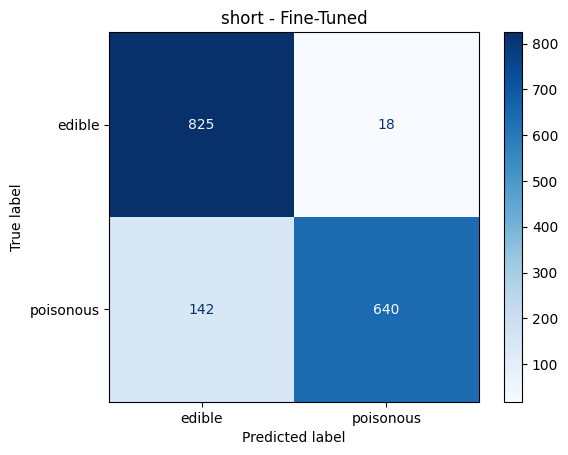

✅ Saved model and tokenizer to ./model_short.zip


================ Prompt Style: VERBOSE ================



Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/6499 [00:00<?, ? examples/s]

Map:   0%|          | 0/1625 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-19-fff2ac2f15e0>:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be

Step,Training Loss
500,0.694400


In [ ]:
for style in prompt_styles:
    print(f"\n\n================ Prompt Style: {style.upper()} ================\n")

    dataset = load_dataset("json", data_files={
        "train": f"./train_{style}.jsonl",
        "test": f"./test_{style}.jsonl"
    })

    def preprocess(example):
        prompt = example["instruction"] + " " + example["input"]
        label = label_map[example["output"].strip().lower()]
        tokenized = tokenizer(prompt, truncation=True, padding="max_length", max_length=256)
        tokenized["labels"] = label
        return tokenized

    tokenized_ds = dataset.map(preprocess)
    train_set, test_set = tokenized_ds["train"], tokenized_ds["test"]

    # Zero-shot
    evaluate_model(base_model, test_set, title=f"{style} - Zero-Shot")

    # LoRA
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )
    model = model.to("cuda" if torch.cuda.is_available() else "cpu")
    ft_model = get_peft_model(model, lora_config)

    from transformers import TrainingArguments
    training_args = TrainingArguments(
        output_dir=f"./results_{style}",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        learning_rate=2e-5,
        disable_tqdm=False
    )

    trainer = Trainer(
        model=ft_model,
        args=training_args,
        train_dataset=train_set,
        eval_dataset=test_set,
        tokenizer=tokenizer,
        data_collator=default_data_collator
    )

    trainer.train()

    evaluate_model(ft_model, test_set, title=f"{style} - Fine-Tuned")

    save_path = f"./model_{style}"
    ft_model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    shutil.make_archive(save_path, 'zip', save_path)
    print(f"✅ Saved model and tokenizer to {save_path}.zip")